In [2]:
# ============================================================
# 0. Setup
# ============================================================
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks


LOG_DIR1 = Path("/home/seram/ut/project/Fast-ECoT/rollouts/libero_object/ECoT_plain")
LOG_DIRS = [LOG_DIR1]

FOCUS_METRICS = ["entropy", "top3_mass"]
WINDOW = 5          # rolling window for delta/window-delta
PREFIX_LEN = 80     # 분석에 사용할 최대 timestep 수

ACTION_TOKEN_BEGIN_IDX = 31743
N_ACTION_BINS = 256
ACTION_TOKEN_START = ACTION_TOKEN_BEGIN_IDX + 1
ACTION_TOKEN_END   = ACTION_TOKEN_START + N_ACTION_BINS

np.random.seed(0)



In [3]:
# ============================================================
# 1. Data structures
# ============================================================
@dataclass
class RolloutRecord:
    task_name: str
    task_id: Any
    trial_id: Any
    rollout_id: str
    success: int
    pt_name: str
    step_ids: np.ndarray
    traj_len: int
    logits: torch.Tensor
    entropy_mean_series: np.ndarray
    top3_mass_mean_series: np.ndarray
    inference_time_series: np.ndarray
    
# ============================================================
# 2. Load rollouts
# ============================================================
def load_rollouts(log_dir: Path| list[Path]) -> List[RolloutRecord]:
    records = []
    if isinstance(log_dir, Path):
        log_dirs = [log_dir]
    else:
        log_dirs = log_dir
    for log_dir in log_dirs:
        for pt_path in sorted(log_dir.glob("*/trial*/*.pt")):
            raw = torch.load(pt_path, map_location="cpu")
            if raw["logits"].numel() == 0:
                continue
            rollout_id = f"{raw['task_id']}_{raw['trial_id']}"
            records.append(RolloutRecord(
            task_name=raw["task_name"],
            task_id=raw["task_id"],
            trial_id=raw["trial_id"],
            rollout_id=rollout_id,
            success=int(raw["success"]),
            pt_name=pt_path.name,
            step_ids=np.asarray(raw["step_ids"]),
            traj_len=int(len(raw["step_ids"])),
            logits=raw["logits"].float(),
            entropy_mean_series=np.asarray(raw["entropy_series"]),
            top3_mass_mean_series=np.asarray(raw["top3_mass_series"]),
            inference_time_series=np.asarray(raw["inference_times"]),
            
        ))
    return records


## Task별 succes rate 및 inference time 평균

In [4]:
rollouts = load_rollouts(LOG_DIRS)
rollout_df = pd.DataFrame([
    dict(task_id=r.task_id, task_name=r.task_name, rollout_id=r.rollout_id,
         success=r.success, traj_len=r.traj_len, inference_time_mean=np.mean(r.inference_time_series),
         num_updates = r.prefix_stats.get("num_prefix_updates", 0),
         num_resets = r.prefix_stats.get("num_prefix_resets", 0),
         num_changes = r.prefix_stats.get("num_prefix_changes", 0),
         num_decisions = r.prefix_stats.get("num_prefix_decisions", 0)
         )    
    for r in rollouts
])
rollout_df["total_time"] = rollout_df["traj_len"] * rollout_df["inference_time_mean"]
rollout_df["cot_ratio"] = rollout_df["num_resets"] / rollout_df["traj_len"]

print(f"Loaded {len(rollouts)} rollouts")

# Create summary with counts and means
summary_df = rollout_df.groupby(["task_id"]).agg({
    "success": ["count", "mean"],  # count gives num_rollouts, mean gives success_rate
    "inference_time_mean": "mean",
    "total_time": "mean",
    "num_updates": "mean",
    "num_resets": "mean",
    "cot_ratio": "mean"
})

# Flatten column names
summary_df.columns = ["num_rollouts", "success_rate", "inference_time_mean", 
                      "total_time", "num_updates", "num_resets", "cot_ratio"]

print(summary_df.round(3))

/tmp/ipykernel_2694213/719998952.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pt_path, map_location="cpu")


Loaded 200 rollouts
success   0   1
task_id        
0        18   2
1         9  11
2         3  17
3        12   8
4         3  17
5        10  10
6         9  11
7        15   5
8         5  15
9         8  12
         success  traj_len  inference_time_mean   total_time
task_id                                                     
0           0.10    272.35             6.517457  1774.631132
1           0.55    229.25             6.088947  1397.929785
2           0.85    142.05             5.854379   832.227805
3           0.40    227.65             5.886651  1340.103480
4           0.85    165.20             5.962263   984.845050
5           0.50    206.05             5.931982  1222.341359
6           0.55    233.75             5.831209  1362.796284
7           0.25    243.75             5.780657  1408.810549
8           0.75    189.35             5.752028  1088.953924
9           0.60    219.25             5.726144  1255.465931


## Task별 traj에 따른 metric (dist probability / far mass x distance) 변화

각 task 내에서 individual traj(회색) + success/fail 평균(색) 을 함께 그린다.

In [9]:
# ============================================================
# 3. Metric computation
# ============================================================
from typing import Dict
import torch.nn.functional as F


def _smooth_probs_1d(probs: torch.Tensor, kernel_size: int = 5) -> torch.Tensor:
    """
    probs: [N, 256]
    returns: [N, 256]
    """
    if kernel_size <= 1:
        return probs
    pad = kernel_size // 2
    weight = torch.ones(1, 1, kernel_size, device=probs.device, dtype=probs.dtype) / kernel_size
    x = probs.unsqueeze(1)  # [N,1,256]
    x = F.pad(x, (pad, pad), mode="replicate")
    y = F.conv1d(x, weight)
    return y.squeeze(1)  # [N,256]


def _local_maxima_mask(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N, B]
    returns bool mask [N, B] for local maxima.
    Plateaus are handled conservatively.
    """
    left = torch.empty_like(x)
    right = torch.empty_like(x)

    left[:, 0] = -torch.inf
    left[:, 1:] = x[:, :-1]

    right[:, -1] = -torch.inf
    right[:, :-1] = x[:, 1:]

    return (x >= left) & (x >= right)


def _top2_peaks(smoothed_probs: torch.Tensor, min_peak_prob: float = 0.0):
    """
    Find top-2 local peaks from smoothed_probs.

    smoothed_probs: [N, B]
    returns:
      peak1_idx, peak2_idx: [N]
      peak1_val, peak2_val: [N]
      has_peak2: [N] bool
    """
    N, B = smoothed_probs.shape
    peak_mask = _local_maxima_mask(smoothed_probs)

    if min_peak_prob > 0:
        peak_mask = peak_mask & (smoothed_probs >= min_peak_prob)

    peak_vals = torch.where(
        peak_mask,
        smoothed_probs,
        torch.full_like(smoothed_probs, -torch.inf),
    )

    top2_vals, top2_idx = torch.topk(peak_vals, k=2, dim=-1)
    peak1_val = top2_vals[:, 0]
    peak2_val = top2_vals[:, 1]
    peak1_idx = top2_idx[:, 0]
    peak2_idx = top2_idx[:, 1]
    has_peak2 = torch.isfinite(peak2_val)

    return peak1_idx, peak2_idx, peak1_val, peak2_val, has_peak2


def _compute_slot_metrics(
    probs: torch.Tensor,
    smooth_kernel: int = 5,
    far_radius: int = 20,
    min_peak_prob: float = 0.01,
) -> Dict[str, torch.Tensor]:
    """
    probs: [N, 256], where N = T * 7 after flattening.
    returns dict of [N] tensors
    """
    N, B = probs.shape
    idx = torch.arange(B, device=probs.device, dtype=probs.dtype)  # [B]

    # 1) Distance-aware dispersion

    # Smoothed distribution for peak finding
    s_probs = _smooth_probs_1d(probs, kernel_size=smooth_kernel)

    # Main peak = MAP on smoothed probs
    map_idx = s_probs.argmax(dim=-1)  # [N]

    ii = torch.arange(B, device=probs.device).unsqueeze(0)  # [1,B]
    # 1) Distance probability
    dist = (ii - map_idx.unsqueeze(1)).abs().to(probs.dtype)             # [N, B]
    far_dist = torch.where(dist > far_radius, dist, torch.zeros_like(dist))  # [N, B]
    dist_entropy = (probs * far_dist).sum(dim=-1) 
    
    # 2) Two far-apart peaks = far_mass x peak_separation
    # Far mass from MAP
    far_mask = (ii - map_idx.unsqueeze(1)).abs() > far_radius # 
    far_mass = (probs * far_mask).sum(dim=-1)  # [N]

    # Top-2 local peaks
    peak1_idx, peak2_idx, peak1_val, peak2_val, has_peak2 = _top2_peaks(
        s_probs, min_peak_prob=min_peak_prob
    )
    peak_separation = (peak1_idx - peak2_idx).abs().to(probs.dtype)
    peak_separation = torch.where(has_peak2, peak_separation, torch.zeros_like(peak_separation))

    far_mass_x_peak_separation = far_mass  * peak_separation


    return {
        "dist_entropy": dist_entropy,                                         # [N]
        "far_mass_x_peak_separation": far_mass_x_peak_separation,             # [N]
    }


def compute_metrics(logits: torch.Tensor) -> Dict[str, np.ndarray]:
    """
    Returns dict of 1-D arrays [T], averaged over 7 action slots.

    Expected:
      logits shape: [T, 7, V] or compatible, where the last dim is vocabulary.
      ACTION_TOKEN_START: inclusive start index of 256 action tokens
      ACTION_TOKEN_END: exclusive end index of 256 action tokens
    """
    al = logits[..., ACTION_TOKEN_START:ACTION_TOKEN_END]   # [T,7,256]
    probs = torch.softmax(al, dim=-1)

    entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=-1).cpu().numpy()          # [T,7]
    top3_mass = torch.topk(probs, k=3, dim=-1).values.sum(dim=-1).cpu().numpy()      # [T,7]

    T, A, B = probs.shape
    flat_probs = probs.reshape(T * A, B)  # [T*7,256]
    # flat_probs = probs[:, :6, :].reshape(-1, probs.shape[-1])  # [T*6, 256]

    slot_metrics = _compute_slot_metrics(
        flat_probs,
        smooth_kernel=5,   # for peak detection only
        far_radius=20,     # "far" means > 20 bins from main peak
        min_peak_prob=0.01 # ignore tiny noise peaks after smoothing
    )

    # Reshape back to [T,7] then average over 7 action slots
    out = {
        "entropy": entropy.mean(axis=1),
        "top3_mass": top3_mass.mean(axis=1),
    }

    for k, v in slot_metrics.items():
        out[k] = v.reshape(T, A).mean(dim=1).cpu().numpy()

    return out

In [10]:
# ============================================================
# 4. Helper functions
# ============================================================
def rolling_mean(x: np.ndarray, w: int) -> np.ndarray:
    return pd.Series(x).rolling(w, min_periods=1).mean().to_numpy()

def compute_delta(x: np.ndarray, w: int = WINDOW) -> np.ndarray:
    """Step-wise delta of rolling mean. Length = T."""
    rm = rolling_mean(x, w)
    return np.diff(rm, prepend=rm[0])  # keep length T

def compute_window_delta(x: np.ndarray, w: int = WINDOW) -> np.ndarray:
    """Rolling mean of delta (smoothed derivative, signed). Length = T."""
    delta = compute_delta(x, w)
    return pd.Series(delta).rolling(w, min_periods=1).mean().to_numpy()

def pad_or_clip(x: np.ndarray, length: int) -> np.ndarray:
    if len(x) >= length:
        return x[:length]
    return np.pad(x, (0, length - len(x)), constant_values=np.nan)

def sem(arr: np.ndarray, axis=0) -> np.ndarray:
    n = np.sum(~np.isnan(arr), axis=axis)
    return np.nanstd(arr, axis=axis) / np.sqrt(np.maximum(n, 1))

In [ ]:
# ============================================================
# 5. Precompute per-rollout series
# ============================================================
# 각 rollout 에 대해 raw metric, delta, window_delta 를 미리 계산해 둠
FOCUS_METRICS = [
    "far_mass_x_peak_separation",
    "dist_entropy",
]
records = []  # list of dicts

for r in rollouts:
    metrics = compute_metrics(r.logits)  # {metric_name: np.ndarray[T]}

    row = {
        "task_name": r.task_name,
        "rollout_id": r.rollout_id,
        "success": r.success,
        "traj_len": r.traj_len,
    }

    for mn in FOCUS_METRICS:
        x = np.asarray(metrics[mn], dtype=np.float32)  # shape [T]

        row[f"{mn}_series"] = x
        row[f"{mn}_delta"] = compute_delta(x)
        row[f"{mn}_window_delta"] = compute_window_delta(x)

        # optional summary stats per rollout
        row[f"{mn}_mean"] = float(np.mean(x))
        row[f"{mn}_max"] = float(np.max(x))
        row[f"{mn}_min"] = float(np.min(x))
        row[f"{mn}_last"] = float(x[-1]) if len(x) > 0 else np.nan

    records.append(row)

print(f"Precomputed series for {len(records)} rollouts.")

Precomputed series for 200 rollouts.


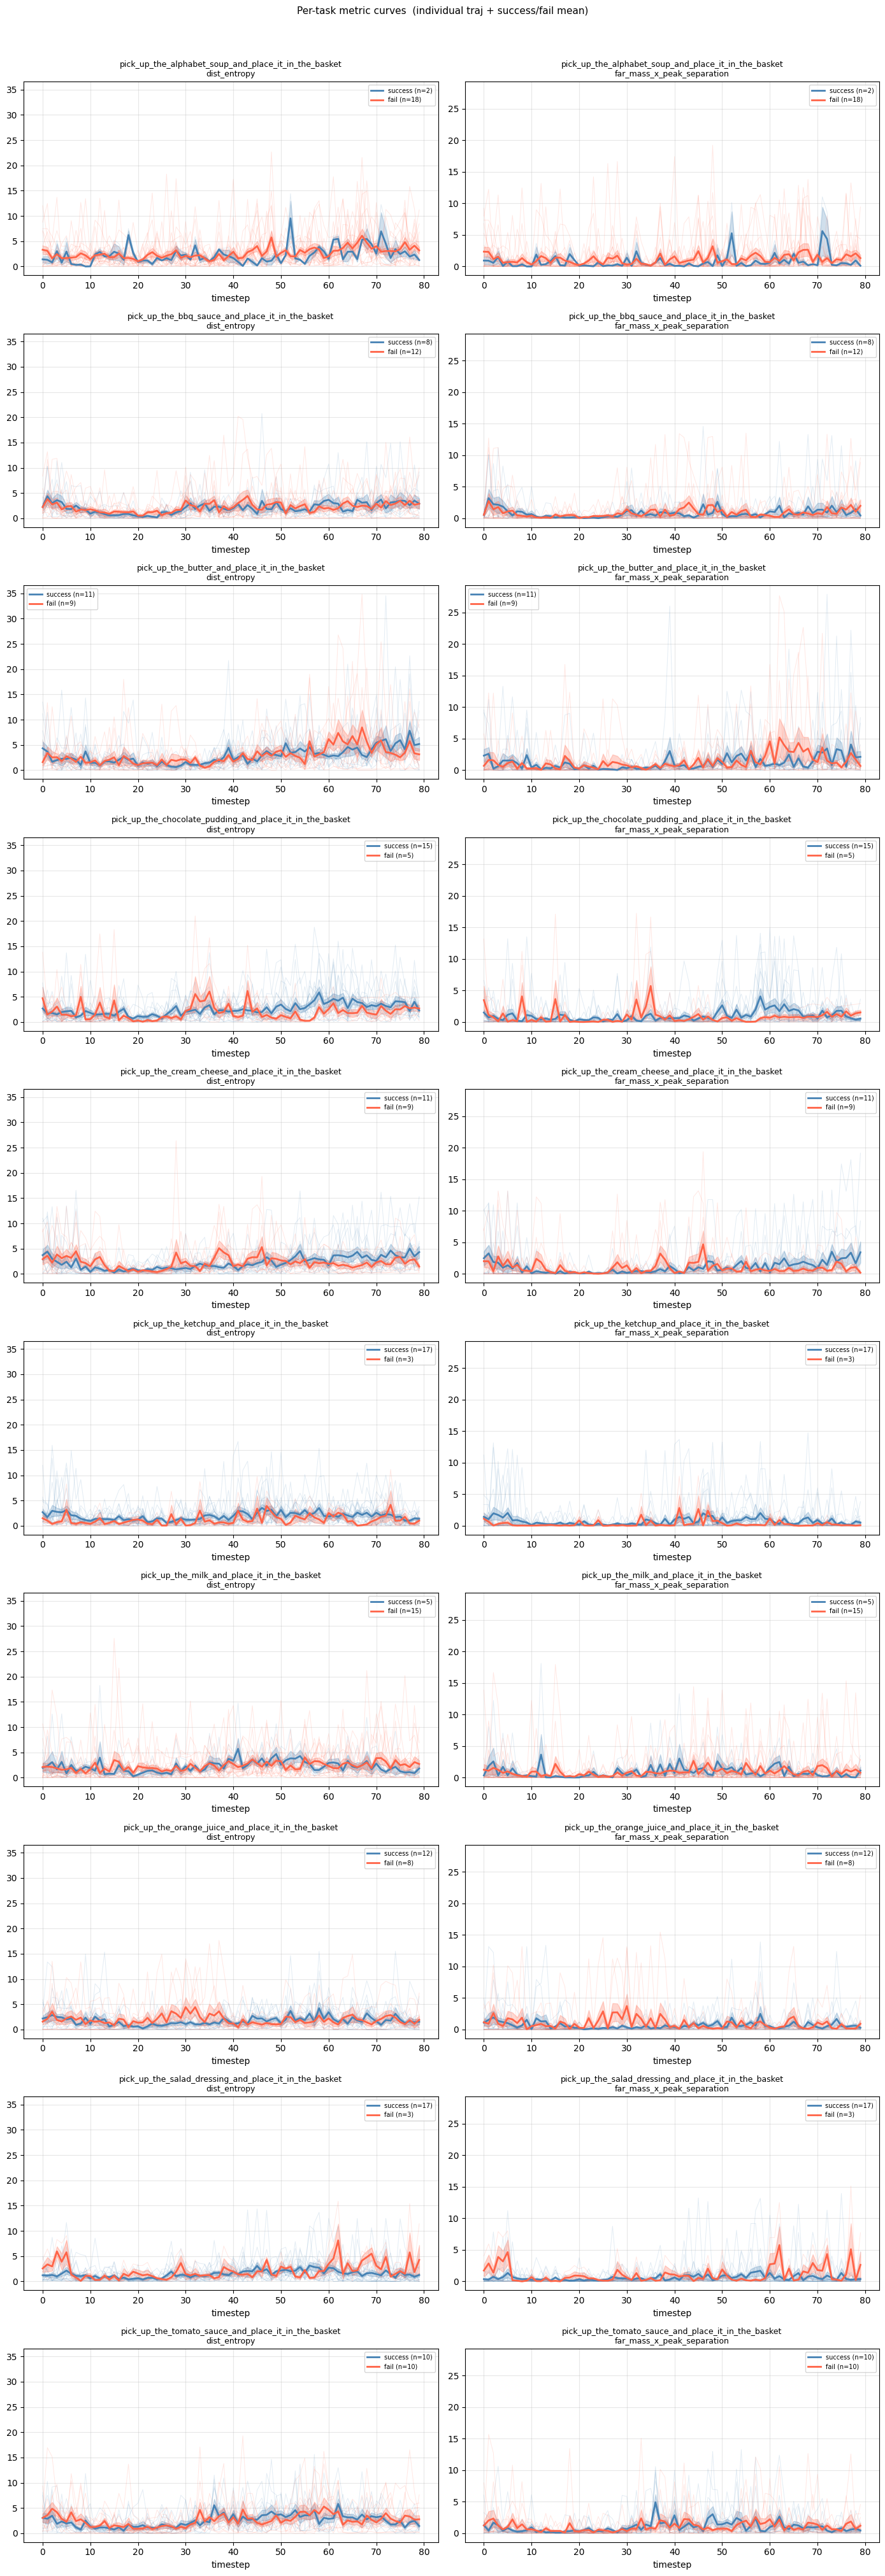

In [12]:
# ============================================================
# Part 1: per-task traj-level metric curves
# ============================================================
task_names = sorted({r["task_name"] for r in records})
n_tasks = len(task_names)
n_metrics = len(FOCUS_METRICS)

fig, axes = plt.subplots(
    n_tasks, n_metrics,
    figsize=(7 * n_metrics, 4 * n_tasks),
    squeeze=False,
    sharey='col',
)
fig.suptitle("Per-task metric curves  (individual traj + success/fail mean)", fontsize=11, y=1.01)

for row_i, task_name in enumerate(task_names):
    task_recs = [r for r in records if r["task_name"] == task_name]

    # median prefix from success traj
    succ_lens = [r["traj_len"] for r in task_recs if r["success"] == 1]
    prefix = int(np.median(succ_lens)) if succ_lens else PREFIX_LEN
    prefix = min(prefix, PREFIX_LEN)

    for col_i, mn in enumerate(FOCUS_METRICS):
        ax = axes[row_i][col_i]

        succ_curves, fail_curves = [], []
        for r in task_recs:
            x = pad_or_clip(r[f"{mn}_series"], prefix)
            if r["success"] == 1:
                succ_curves.append(x)
            else:
                fail_curves.append(x)

        t_axis = np.arange(prefix)

        # individual trajs (light)
        for x in succ_curves:
            ax.plot(t_axis, x, color="steelblue", alpha=0.15, linewidth=0.7)
        for x in fail_curves:
            ax.plot(t_axis, x, color="tomato", alpha=0.15, linewidth=0.7)

        # mean ± SEM (n-adjusted)
        for curves, color, label in [
            (succ_curves, "steelblue", "success"),
            (fail_curves, "tomato",    "fail"),
        ]:
            if not curves:
                continue
            arr = np.stack(curves)  # [N, T]
            n   = len(curves)
            mean = np.nanmean(arr, axis=0)
            se   = np.nanstd(arr, axis=0) / np.sqrt(max(n, 1))
            ax.plot(t_axis, mean, color=color, linewidth=2, label=f"{label} (n={n})")
            ax.fill_between(t_axis, mean - se, mean + se, color=color, alpha=0.25)

        ax.set_title(f"{task_name}\n{mn}", fontsize=9)
        ax.set_xlabel("timestep")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

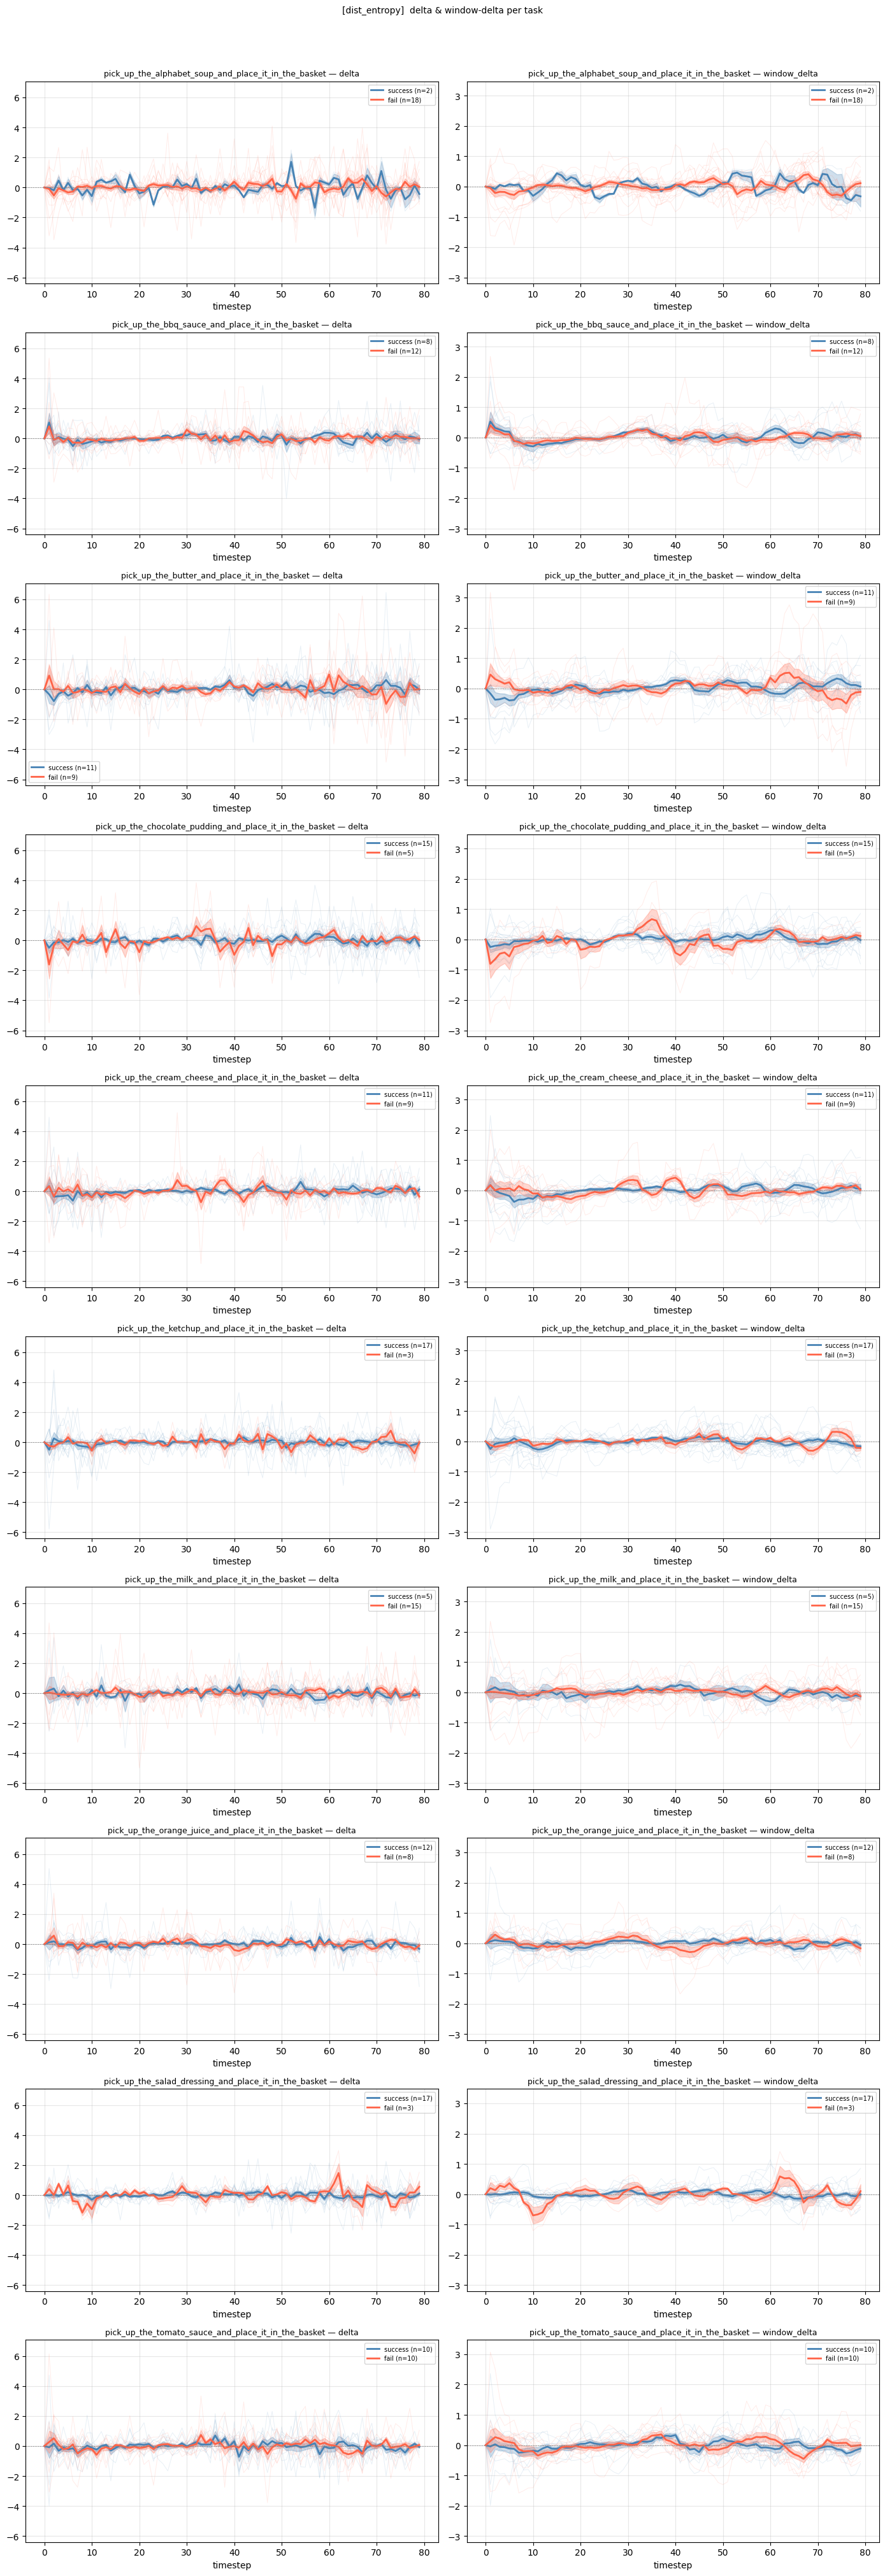

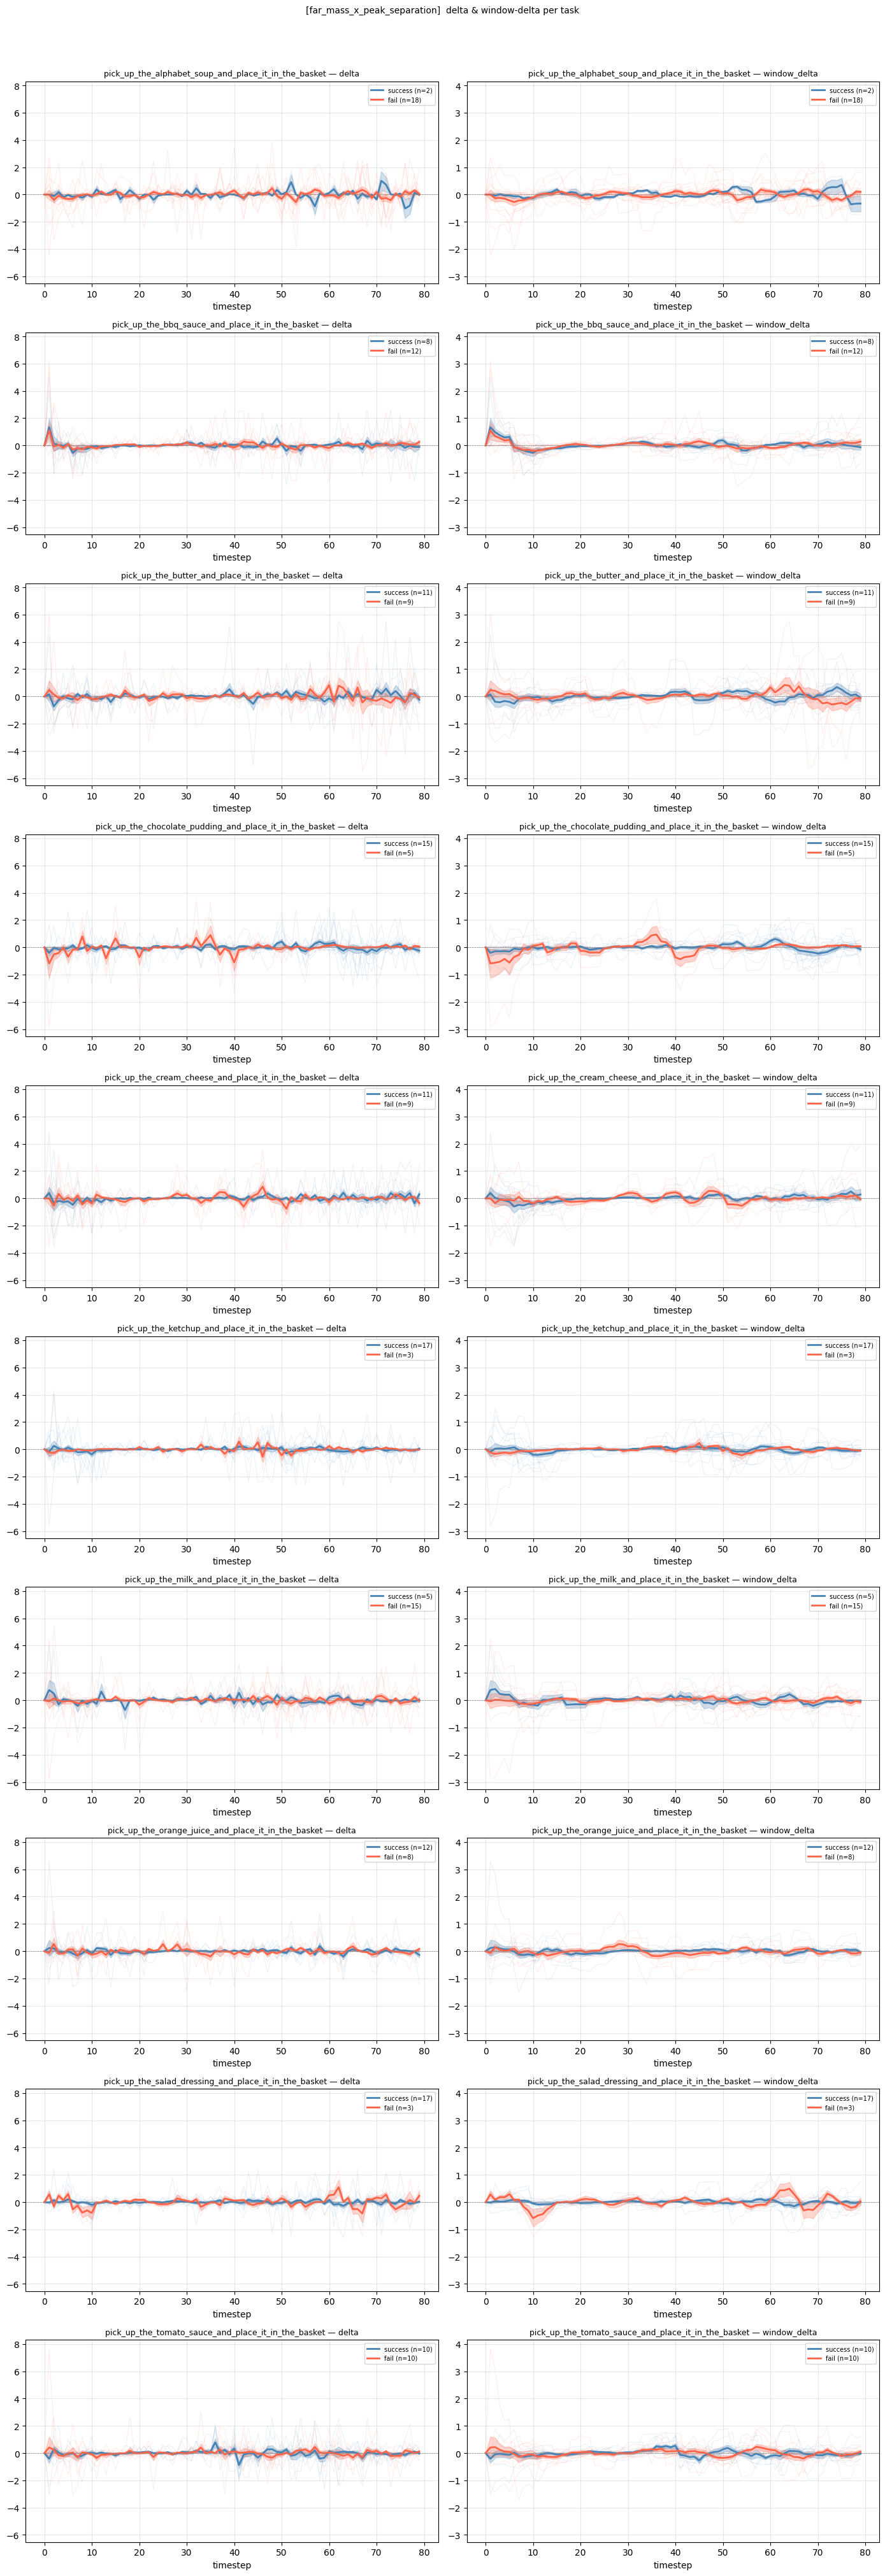

In [13]:
# ============================================================
# Part 2: delta & window-delta curves per task
# ============================================================
for mn in FOCUS_METRICS:
    fig, axes = plt.subplots(
        n_tasks, 2,
        figsize=(14, 4 * n_tasks),
        squeeze=False,
        sharey='col',
    )
    fig.suptitle(f"[{mn}]  delta & window-delta per task\n", fontsize=10, y=1.01)

    for row_i, task_name in enumerate(task_names):
        task_recs = [r for r in records if r["task_name"] == task_name]

        succ_lens = [r["traj_len"] for r in task_recs if r["success"] == 1]
        prefix = int(np.median(succ_lens)) if succ_lens else PREFIX_LEN
        prefix = min(prefix, PREFIX_LEN)
        t_axis = np.arange(prefix)

        for col_i, key_suffix in enumerate(["delta", "window_delta"]):
            ax = axes[row_i][col_i]
            key = f"{mn}_{key_suffix}"

            succ_curves, fail_curves = [], []
            for r in task_recs:
                x = pad_or_clip(r[key], prefix)
                if r["success"] == 1:
                    succ_curves.append(x)
                else:
                    fail_curves.append(x)

            # individual trajs (light background)
            for x in succ_curves:
                ax.plot(t_axis, x, color="steelblue", alpha=0.12, linewidth=0.7)
            for x in fail_curves:
                ax.plot(t_axis, x, color="tomato", alpha=0.12, linewidth=0.7)

            # mean ± std (n-adjusted SEM band)
            for curves, color, label in [
                (succ_curves, "steelblue", "success"),
                (fail_curves, "tomato",    "fail"),
            ]:
                if not curves:
                    continue
                arr  = np.stack(curves)  # [N, T]
                n    = len(curves)
                mean = np.nanmean(arr, axis=0)
                se   = np.nanstd(arr, axis=0) / np.sqrt(max(n, 1))
                ax.plot(t_axis, mean, color=color, linewidth=2,
                        label=f"{label} (n={n})")
                ax.fill_between(t_axis, mean - se, mean + se,
                                color=color, alpha=0.25)

            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.set_title(f"{task_name} — {key_suffix}", fontsize=9)
            ax.set_xlabel("timestep")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# (For threshold)
## 모든 task, 모든 episode에 대한 time step 별 metric 변화 추이

In [ ]:
def compute_avg_total_variation(x):
    """
    x: 1-D metric series of length T
    returns: 1-D series y of length T
        y[t] = windowed average total variation up to step t
    """
    x = np.asarray(x, dtype=np.float64)
    T = len(x)
    y = np.zeros(T, dtype=np.float64)

    for t in range(T):
        start = 0
        seg = x[start:t + 1]
        if len(seg) < 2:
            y[t] = 0.0
        else:
            y[t] = np.nanmean(np.abs(np.diff(seg)))
    return y

def compute_windowed_avg_total_variation(x, window=5):
    """
    x: 1-D metric series of length T
    returns: 1-D series y of length T
        y[t] = windowed average total variation up to step t
    """
    x = np.asarray(x, dtype=np.float64)
    T = len(x)
    y = np.zeros(T, dtype=np.float64)

    for t in range(T):
        start = max(0, t - window + 1)
        seg = x[start:t + 1]
        if len(seg) < 2:
            y[t] = 0.0
        else:
            y[t] = np.nanmean(np.abs(np.diff(seg)))
    return y

def pad_with_nan(arrs):
    T = max(len(a) for a in arrs)
    out = np.full((len(arrs), T), np.nan, dtype=np.float64)
    for i, a in enumerate(arrs):
        out[i, :len(a)] = a
    return out

def plot_mean_any_metric(rollouts, metric_name, window=5, method:str="windowed_total_variance"):
    # Define axis ranges for each metric
    axis_ranges = {
        "far_mass_x_peak_separation": {"xlim": (0, 200), "ylim": (0, 7)},
        "bimodal_u": {"xlim": (0, 200), "ylim": (0, 4)},
        "second_peak_mass_x_peak_distance": {"xlim": (0, 200), "ylim": (0, 7)},
        "dist_aware_dispersion": {"xlim": (0, 200), "ylim": (0, 250)},
    }
    
    # Get ranges for this metric, with defaults if not found
    ranges = axis_ranges.get(metric_name, {"xlim": (0, 200), "ylim": (0, 5)})
    xlim = ranges["xlim"]
    ylim = ranges["ylim"]
    
    succ = []
    fail = []

    for r in rollouts:
        metrics = compute_metrics(r.logits)
        x = np.asarray(metrics[metric_name], dtype=np.float64)
        # smooth x over window size 5
        x = np.convolve(x, np.ones(window)/window, mode='same')
        if "value" in method or "metric" in method:
            scores = x
        elif method == "total_variance":
            scores = compute_avg_total_variation(x)
        elif method == "windowed_total_variance":
            scores = compute_windowed_avg_total_variation(x, window=window)

        if r.success == 1:
            succ.append(scores)
        else:
            fail.append(scores)

    plt.figure(figsize=(8, 4))

    if succ:
        S = pad_with_nan(succ)
        plt.plot(np.nanmean(S, axis=0), label="success")
    if fail:
        F = pad_with_nan(fail)
        plt.plot(np.nanmean(F, axis=0), label="fail")

    plt.title(f"Mean online {method}: {metric_name} (window={window})")
    plt.xlabel("time index")
    plt.ylabel(f"{method}")
    
    # Apply axis ranges
    plt.xlim(xlim)
    plt.ylim(ylim)
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# plain score
plot_mean_any_metric(rollouts, "far_mass_x_peak_separation", method="windowed_value", window=1)
plot_mean_any_metric(rollouts, "dist_entropy", method="windowed_value", window=1)
plot_mean_any_metric(rollouts, "entropy", method="windowed_value", window=1)
# average score(window=5)
plot_mean_any_metric(rollouts, "far_mass_x_peak_separation", method="windowed_value", window=5)
plot_mean_any_metric(rollouts, "dist_entropy", method="windowed_value", window=5)
plot_mean_any_metric(rollouts, "entropy", method="windowed_value", window=5)
# plain total variance
plot_mean_any_metric(rollouts, "far_mass_x_peak_separation", method="total_variance", window=5)
plot_mean_any_metric(rollouts, "dist_entropy", method="total_variance", window=5)
plot_mean_any_metric(rollouts, "entropy", method="total_variance", window=5)
# average total variance(window=5)
plot_mean_any_metric(rollouts, "far_mass_x_peak_separation", method="windowed_total_variance", window=5)
plot_mean_any_metric(rollouts, "dist_entropy", method="windowed_total_variance", window=5)
plot_mean_any_metric(rollouts, "entropy", method="windowed_total_variance", window=5)
